# Strong Coupling Expansion: Benchmarks on the dimer
Expansion around the atomic limit $t=0$ of various quantities the dimer

## Partition function and Thermodynamic potential

Exact partition function for the dimer and $\Omega = - \ln Z$ thermodynamic potential. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from series import calculate_coeffs, partial_sum, estimate_radius
from plot_complex import complex_array_to_rgb
from hubbard_sc_exp import HubbardED

In [3]:
#exact atomic partition function
def Z_atomic(U:float,beta:float,mu:float):
    return 1+ 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))



#exact dimer partition function
Eplus = lambda t,U: U/2 + np.sqrt(U**2/4 + 4*t**2)
Eminus = lambda t,U: U/2 - np.sqrt(U**2/4 + 4*t**2)
def Z(t:float,U:float,beta:float,mu:float):

    A = 1 + 2*np.exp(-beta*(-t-mu)) + 2*np.exp(-beta*(t-mu)) + 3*np.exp(2*beta*mu) + np.exp(-beta*(U-2*mu))
    B = np.exp(-beta*(Eplus(t,U)-2*mu)) + np.exp(-beta*(Eminus(t,U)-2*mu))
    C = 2*np.exp(-beta*(U+t-3*mu)) +2*np.exp(-beta*(U-t-3*mu)) + np.exp(-2*beta*U + 4 * beta * mu) 

    return A+B+C


#exact dimer thermodynamic potential
def logZ(t:float,U:float,beta:float,mu:float):
    return -1.0/2*np.log(Z(t,U,beta,mu)) #free energy per site

Plot of $Z(t)$ in the complex plane (left) and on the right the corresponding summed series for $-\ln Z$ truncated at finite order. 

In [4]:
#create a meshgrid of complex hopping values from -a to a. 
def get_tgrid(a:float, b:float, npoints:int):
    treal = np.linspace(a, b, npoints)
    tr, ti = np.meshgrid(treal, treal)
    return tr + 1j*ti

In [5]:
U = 8.0
beta = 3.0
mu = 2.0
r = 1.0 # radius for the complex plane plot
N = 500 # number of points in the circle of radius r to sample

a = -1.5
b = 1.5

#ln(Z(z))
z = np.linspace(0,b,100)
logpart = logZ(z,U,beta,mu)

#orders for plotting summation
orders = [4,6,8]
vals = []

for order in orders:
    logZapprox = partial_sum(z, N, logZ, order, r, U, beta, mu)
    vals.append(logZapprox)


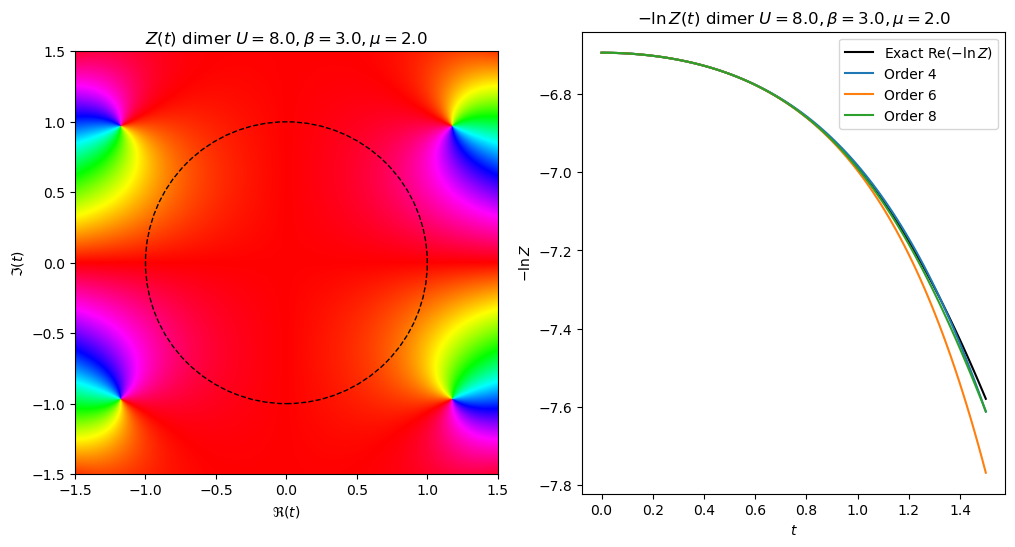

In [6]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12,6))

tgrid = get_tgrid(a,b, N)
Zgrid = Z(tgrid,U,beta,mu)

ax1.imshow(complex_array_to_rgb(Zgrid, rmax=4), extent=(a,b,a,b))
ax1.set_title(rf"$Z(t)$ dimer $U={U}, \beta={beta}, \mu={mu}$")
ax1.set_xlabel(r"$\Re(t)$")
ax1.set_ylabel(r"$\Im(t)$")

#rad = estimate_radius(f=lambda t: Z(t,U,beta,mu), max_order=10, r=r, N=N)
ax1.add_artist(plt.Circle((0,0), 1.0, color='black', fill=False, linestyle='dashed'))


ax2.plot(z, logpart.real, label=r"Exact Re($-\ln Z$)", color='black')

for i, order in enumerate(orders):
    ax2.plot(z, vals[i].real, label=rf"Order {order}")

ax2.set_title(rf"$-\ln Z(t)$ dimer $U={U}, \beta={beta}, \mu={mu}$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$-\ln Z$")
ax2.legend()

## Density $\langle \hat N \rangle$

In [7]:
def calculate_N_dimer(t,U, beta, mu, hub: HubbardED):


    neighbors_and_t = [(0,1,t)]

    top = 0.0
    bot = 0.0
    for sector in hub.basis:

        state = list(sector.keys())[0]
        N = bin(state).count('1')

        Ht = hub.Hamiltonian_Hopping(neighbors_and_t, sector)
        Hu, Hmu = hub.Hamiltonian_Diag(sector)

        H = Ht + U*Hu + mu*Hmu
        E = np.linalg.eigvals(H)
        top += N*np.sum(np.exp(-beta*E))
        bot += np.sum(np.exp(-beta*E))
        

    if bot < 1e-10:
        return np.nan
    res = top / bot

    return res


def robust_complex_to_rgb(X, rmax=None):
    """Handle NaNs gracefully for domain coloring"""
    # Create a mask for NaNs (poles)
    mask = np.isnan(X) | np.isinf(X)
    X_safe = np.where(mask, 0, X) # Replace NaNs with 0 temp
    
    rgb = complex_array_to_rgb(X_safe, rmax=rmax)
    
    # Turn NaNs into pure white (or black) to make poles visible
    rgb[mask] = [1.0, 1.0, 1.0] 
    return rgb

In [8]:
hub = HubbardED(2)
mus = np.linspace(0,U,50)
t = 1.0
N_vect = np.vectorize(calculate_N_dimer, excluded=['hub'])

Nmu = N_vect(t, U, beta, mus, hub)

Text(0, 0.5, '$\\langle \\hat N \\rangle$')

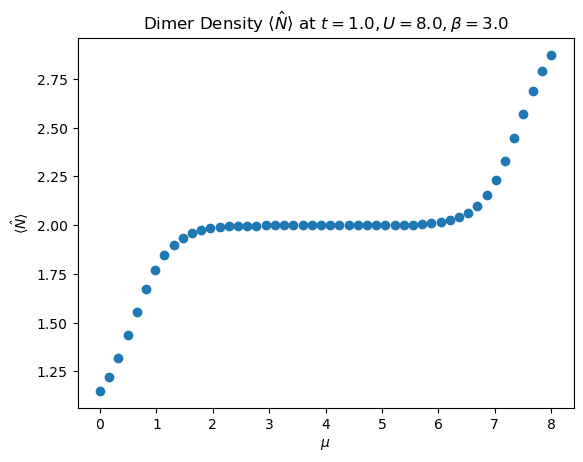

In [9]:
plt.scatter(mus, Nmu.real)
plt.title(rf"Dimer Density $\langle \hat N \rangle$ at $t={t}, U={U}, \beta={beta}$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\langle \hat N \rangle$")

In [10]:
tgrid = get_tgrid(a,b, N)
a = -3.0; b=3.0
N = 300

Ngrid = N_vect(tgrid, U, beta, mu, hub)

In [11]:
orders = [4,6,8]
vals = []

for order in orders:
    Napprox = partial_sum(z, N, N_vect, order, r, U, beta, mu, hub)
    vals.append(Napprox)

ts = np.linspace(0,1.5,100)
Nexact = N_vect(ts, U, beta, mu, hub)

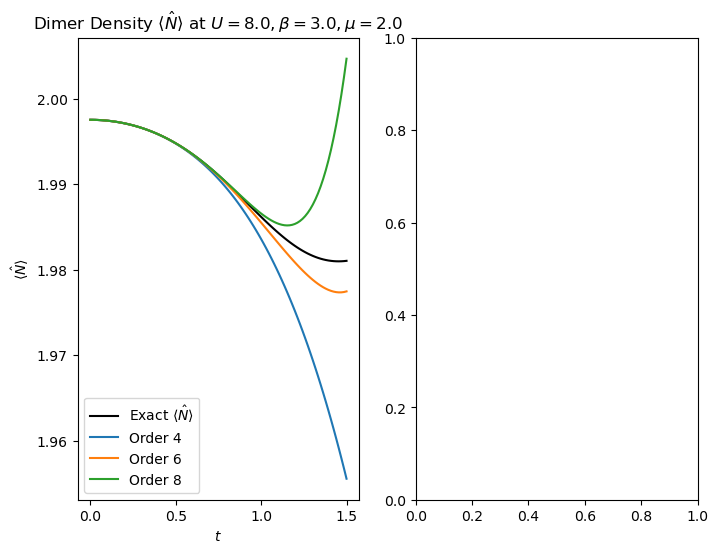

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(8,6))


ax2.plot(ts, Nexact.real, label=r"Exact $\langle \hat N \rangle$", color='black')
for i, order in enumerate(orders):
    ax1.plot(z, vals[i].real, label=rf"Order {order}")

ax2.set_title(rf"Dimer Density $\langle \hat N \rangle$ at $U={U}, \beta={beta}, \mu={mu}$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$\langle \hat N \rangle$")
ax2.legend()
